In [1]:
import os
import numpy as np
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

MODEL_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth"

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

print("Classes:")
for i, name in enumerate(classes):
    print(i, ":", name)

Classes:
0 : crazing
1 : inclusion
2 : patches
3 : pitted_surface
4 : rolled-in_scale
5 : scratches


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformation ready")

Transformation ready


In [4]:
validation_path = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

validation_dataset = ImageFolder(
    validation_path,
    transform=transform
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation images:", len(validation_dataset))
print("Classes:", validation_dataset.classes)

Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    6
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict):

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint.state_dict()

new_state_dict = {}

for key, value in state_dict.items():

    if key.startswith("module."):
        key = key[7:]

    new_state_dict[key] = value

model.load_state_dict(
    new_state_dict,
    strict=True
)

model.to(device)
model.eval()

print("Model loaded successfully")
print("Device:", device)

Model loaded successfully
Device: cpu


In [6]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print("Predictions generated:", len(all_predictions))

Predictions generated: 360


In [7]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("=" * 60)

MODEL PERFORMANCE
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1 Score  : 100.00%


In [8]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=classes,
    zero_division=0
)

print(report)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      1.00      1.00        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      1.00      1.00        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       1.00      1.00      1.00        60

       accuracy                           1.00       360
      macro avg       1.00      1.00      1.00       360
   weighted avg       1.00      1.00      1.00       360



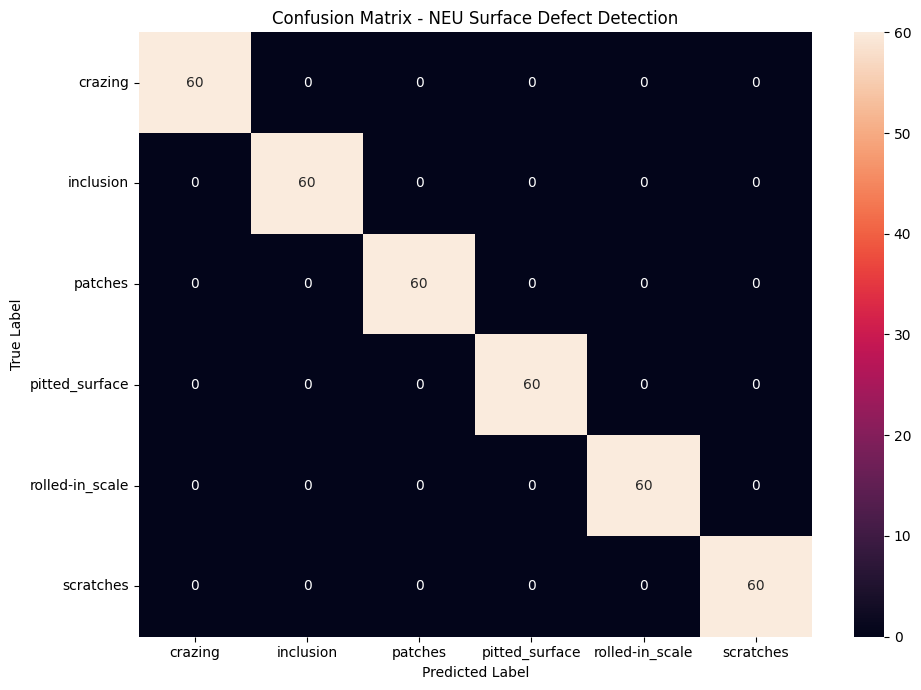

In [9]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - NEU Surface Defect Detection")

plt.tight_layout()
plt.show()

In [10]:
cm = np.array(cm)

class_accuracy = (
    cm.diagonal()
    /
    cm.sum(axis=1)
)

print("=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)

for class_name, acc in zip(
    classes,
    class_accuracy
):

    print(
        f"{class_name:20s}: {acc * 100:.2f}%"
    )

PER-CLASS ACCURACY
crazing             : 100.00%
inclusion           : 100.00%
patches             : 100.00%
pitted_surface      : 100.00%
rolled-in_scale     : 100.00%
scratches           : 100.00%


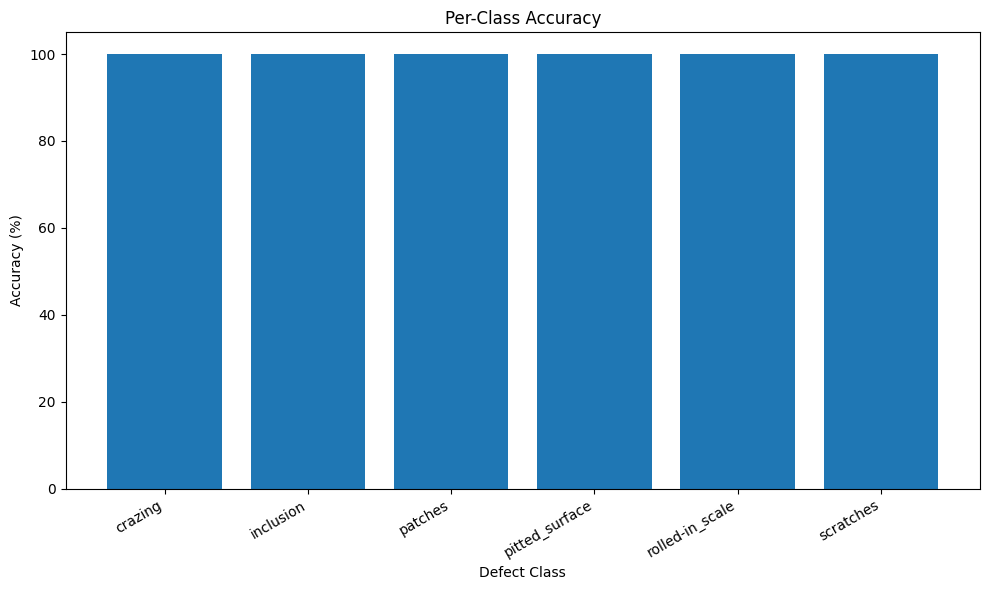

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    classes,
    class_accuracy * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Defect Class")
plt.title("Per-Class Accuracy")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

In [12]:
print("=" * 60)
print("DAY 13 - MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"Validation Images : {len(all_labels)}")
print(f"Accuracy          : {accuracy * 100:.2f}%")
print(f"Precision         : {precision * 100:.2f}%")
print(f"Recall            : {recall * 100:.2f}%")
print(f"F1 Score          : {f1 * 100:.2f}%")

print("=" * 60)
print("Evaluation completed successfully.")
print("=" * 60)

DAY 13 - MODEL PERFORMANCE SUMMARY
Validation Images : 360
Accuracy          : 100.00%
Precision         : 100.00%
Recall            : 100.00%
F1 Score          : 100.00%
Evaluation completed successfully.
